In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

pd.set_option("display.max_columns", 100)

# Load data and join

In [2]:
customer_profil = pd.read_csv("D:\\PythonProject\\python-for-ai\\day36-CRM-POS-data\\datasets\\customer_profile_dataset.csv")
products_datasets = pd.read_csv("D:\\PythonProject\\python-for-ai\\day36-CRM-POS-data\\datasets\\products_dataset.csv")
purchase_history = pd.read_csv("D:\\PythonProject\\python-for-ai\\day36-CRM-POS-data\\datasets\\purchase_history_dataset.csv")

In [3]:
customer_profil.head()

,customer_id,first_name,last_name,gender,date_of_birth,email,phone_number,signup_date,address,city,state,zip_code
0,1,Robert,Smith,Female,1994-06-14 21:40:27,jane.davis1@mail.com,634-106-4981,2016-10-16 17:23:25,8465 Main St,San Antonio,CA,35566
1,2,Emily,Garcia,Female,1989-09-21 17:56:31,robert.williams2@mail.com,386-635-5998,2021-04-04 14:24:06,305 Main St,New York,AZ,23187
2,3,Jessica,Brown,Male,1984-01-21 21:43:13,emily.davis3@mail.com,627-341-5213,2018-04-22 04:51:57,5725 Oak St,Chicago,AZ,99188
3,4,Michael,Brown,Male,1986-02-06 13:09:53,jessica.williams4@mail.com,126-662-8981,2018-07-06 17:45:14,8468 Oak St,Los Angeles,TX,77421
4,5,Robert,Jones,Male,1996-12-05 05:10:11,robert.martinez5@mail.com,758-947-2802,2018-03-11 01:43:10,2820 Maple St,Chicago,TX,36281


In [4]:
products_datasets.head()

,product_id,product_name,category,price_per_unit,brand,product_description
0,1,Butter,Dairy,28.58,BrandB,Description for Rice
1,2,Butter,Meats,22.66,BrandB,Description for Banana
2,3,Milk,Meats,26.52,BrandE,Description for Banana
3,4,Banana,Grains,26.12,BrandB,Description for Apple
4,5,Rice,Fruits,21.94,BrandD,Description for Banana


In [5]:
purchase_history.head()

,purchase_id,customer_id,product_id,purchase_date,quantity,total_amount
0,1,1,42,2018-04-15 14:08:01,3,37.642074
1,2,1,138,2022-07-10 23:33:47,4,70.247106
2,3,1,403,2021-12-31 03:53:33,3,89.168896
3,4,1,193,2017-01-14 01:25:11,2,59.705059
4,5,1,26,2018-04-06 11:01:06,3,101.778864


We join all the table

In [6]:
# We left-join purchase_history with customer_profil
# We use left join because if we have purchase history with non-member (does not have customer_id) not missing
df_merged = pd.merge(purchase_history, customer_profil, on='customer_id', how='left')
df_merged

,purchase_id,customer_id,product_id,purchase_date,quantity,total_amount,first_name,last_name,gender,date_of_birth,email,phone_number,signup_date,address,city,state,zip_code
0,1,1,42,2018-04-15 14:08:01,3,37.642074,Robert,Smith,Female,1994-06-14 21:40:27,jane.davis1@mail.com,634-106-4981,2016-10-16 17:23:25,8465 Main St,San Antonio,CA,35566
1,2,1,138,2022-07-10 23:33:47,4,70.247106,Robert,Smith,Female,1994-06-14 21:40:27,jane.davis1@mail.com,634-106-4981,2016-10-16 17:23:25,8465 Main St,San Antonio,CA,35566
2,3,1,403,2021-12-31 03:53:33,3,89.168896,Robert,Smith,Female,1994-06-14 21:40:27,jane.davis1@mail.com,634-106-4981,2016-10-16 17:23:25,8465 Main St,San Antonio,CA,35566
3,4,1,193,2017-01-14 01:25:11,2,59.705059,Robert,Smith,Female,1994-06-14 21:40:27,jane.davis1@mail.com,634-106-4981,2016-10-16 17:23:25,8465 Main St,San Antonio,CA,35566
4,5,1,26,2018-04-06 11:01:06,3,101.778864,Robert,Smith,Female,1994-06-14 21:40:27,jane.davis1@mail.com,634-106-4981,2016-10-16 17:23:25,8465 Main St,San Antonio,CA,35566
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10303,10304,999,206,2021-05-08 19:51:52,4,71.482414,Jane,Johnson,Male,1967-02-18 03:49:13,robert.johnson999@mail.com,784-272-6378,2020-03-01 10:51:12,8964 Oak St,New York,TX,69806
10304,10305,999,393,2023-02-27 21:01:24,2,84.344228,Jane,Johnson,Male,1967-02-18 03:49:13,robert.johnson999@mail.com,784-272-6378,2020-03-01 10:51:12,8964 Oak St,New York,TX,69806
10305,10306,999,473,2021-04-22 04:04:08,2,80.146698,Jane,Johnson,Male,1967-02-18 03:49:13,robert.johnson999@mail.com,784-272-6378,2020-03-01 10:51:12,8964 Oak St,New York,TX,69806
10306,10307,1000,453,2023-01-09 20:22:18,2,39.787062,William,Williams,Female,1989-09-03 01:58:10,william.martinez1000@mail.com,489-907-3952,2019-03-17 01:44:21,5850 Oak St,Phoenix,CA,56142


In [7]:
# We do same for another dataset left
df_final = pd.merge(df_merged, products_datasets, on='product_id', how='left')
df_final

,purchase_id,customer_id,product_id,purchase_date,quantity,total_amount,first_name,last_name,gender,date_of_birth,email,phone_number,signup_date,address,city,state,zip_code,product_name,category,price_per_unit,brand,product_description
0,1,1,42,2018-04-15 14:08:01,3,37.642074,Robert,Smith,Female,1994-06-14 21:40:27,jane.davis1@mail.com,634-106-4981,2016-10-16 17:23:25,8465 Main St,San Antonio,CA,35566,Milk,Fruits,21.63,BrandD,Description for Bread
1,2,1,138,2022-07-10 23:33:47,4,70.247106,Robert,Smith,Female,1994-06-14 21:40:27,jane.davis1@mail.com,634-106-4981,2016-10-16 17:23:25,8465 Main St,San Antonio,CA,35566,Bread,Grains,25.98,BrandE,Description for Bread
2,3,1,403,2021-12-31 03:53:33,3,89.168896,Robert,Smith,Female,1994-06-14 21:40:27,jane.davis1@mail.com,634-106-4981,2016-10-16 17:23:25,8465 Main St,San Antonio,CA,35566,Bread,Meats,24.01,BrandD,Description for Banana
3,4,1,193,2017-01-14 01:25:11,2,59.705059,Robert,Smith,Female,1994-06-14 21:40:27,jane.davis1@mail.com,634-106-4981,2016-10-16 17:23:25,8465 Main St,San Antonio,CA,35566,Bread,Grains,29.67,BrandC,Description for Rice
4,5,1,26,2018-04-06 11:01:06,3,101.778864,Robert,Smith,Female,1994-06-14 21:40:27,jane.davis1@mail.com,634-106-4981,2016-10-16 17:23:25,8465 Main St,San Antonio,CA,35566,Bread,Meats,20.58,BrandE,Description for Banana
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10303,10304,999,206,2021-05-08 19:51:52,4,71.482414,Jane,Johnson,Male,1967-02-18 03:49:13,robert.johnson999@mail.com,784-272-6378,2020-03-01 10:51:12,8964 Oak St,New York,TX,69806,Butter,Fruits,13.30,BrandC,Description for Eggs
10304,10305,999,393,2023-02-27 21:01:24,2,84.344228,Jane,Johnson,Male,1967-02-18 03:49:13,robert.johnson999@mail.com,784-272-6378,2020-03-01 10:51:12,8964 Oak St,New York,TX,69806,Pasta,Grains,19.51,BrandB,Description for Banana
10305,10306,999,473,2021-04-22 04:04:08,2,80.146698,Jane,Johnson,Male,1967-02-18 03:49:13,robert.johnson999@mail.com,784-272-6378,2020-03-01 10:51:12,8964 Oak St,New York,TX,69806,Bread,Dairy,8.27,BrandE,Description for Chicken
10306,10307,1000,453,2023-01-09 20:22:18,2,39.787062,William,Williams,Female,1989-09-03 01:58:10,william.martinez1000@mail.com,489-907-3952,2019-03-17 01:44:21,5850 Oak St,Phoenix,CA,56142,Butter,Grains,24.50,BrandD,Description for Butter


# Exploratory Data Analysis (EDA) & Cleaning Data

In [8]:
print('Dataset shape:', df_final.shape)
df_final.info()

Dataset shape: (10308, 22)
<class 'pandas.DataFrame'>
RangeIndex: 10308 entries, 0 to 10307
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   purchase_id          10308 non-null  int64  
 1   customer_id          10308 non-null  int64  
 2   product_id           10308 non-null  int64  
 3   purchase_date        10308 non-null  str    
 4   quantity             10308 non-null  int64  
 5   total_amount         10308 non-null  float64
 6   first_name           10308 non-null  str    
 7   last_name            10308 non-null  str    
 8   gender               10308 non-null  str    
 9   date_of_birth        10308 non-null  str    
 10  email                10308 non-null  str    
 11  phone_number         10308 non-null  str    
 12  signup_date          10308 non-null  str    
 13  address              10308 non-null  str    
 14  city                 10308 non-null  str    
 15  state               

In [9]:
df_final.isna().sum()

purchase_id            0
customer_id            0
product_id             0
purchase_date          0
quantity               0
total_amount           0
first_name             0
last_name              0
gender                 0
date_of_birth          0
email                  0
phone_number           0
signup_date            0
address                0
city                   0
state                  0
zip_code               0
product_name           0
category               0
price_per_unit         0
brand                  0
product_description    0
dtype: int64

In [10]:
df_final.duplicated().sum()

np.int64(0)

In [11]:
df_final.describe()

,purchase_id,customer_id,product_id,quantity,total_amount,zip_code,price_per_unit
count,10308.000000,10308.000000,10308.000000,10308.000000,10308.000000,10308.000000,10308.000000
mean,5154.500000,504.540648,251.363795,3.030656,77.423841,56354.370877,16.004004
std,2975.807621,292.026758,143.690280,1.412852,58.719304,25667.803143,8.534932
min,1.000000,1.000000,1.000000,1.000000,1.526648,10074.000000,0.510000
25%,2577.750000,245.750000,127.000000,2.000000,30.143436,35211.000000,8.950000
50%,5154.500000,510.000000,253.000000,3.000000,62.499946,57118.000000,16.450000
75%,7731.250000,758.000000,375.250000,4.000000,113.776378,78860.000000,23.392500
max,10308.000000,1000.000000,500.000000,5.000000,249.963513,99969.000000,29.970000


In [12]:
df_tp = df_final.copy()

# Question 1: Who is top 20% customer and spend 80% to revenue (Pareto Analysis)

In [13]:
# display descending revenue_per_unit 
df_tp['total_per_unit'] = df_tp['quantity'] * df_tp['price_per_unit']
df_order = df_tp.groupby('product_name')['total_per_unit'].sum().reset_index().sort_values(by='total_per_unit', ascending=False).reset_index(drop=True)
df_order

,product_name,total_per_unit
0,Bread,62379.59
1,Pasta,62099.43
2,Rice,57942.91
3,Eggs,57243.92
4,Butter,54540.12
5,Apple,49432.57
6,Milk,42616.81
7,Banana,38701.91
8,Chicken,38310.60
9,Cheese,37516.50


In [14]:
# count cumulative of money and precentage
df_order['cum_money'] = df_order['total_per_unit'].cumsum()
total_money = df_order['total_per_unit'].sum()
df_order['cum_precentage'] = (df_order['cum_money'] / total_money) * 100
df_order

,product_name,total_per_unit,cum_money,cum_precentage
0,Bread,62379.59,62379.59,12.456377
1,Pasta,62099.43,124479.02,24.856811
2,Rice,57942.91,182421.93,36.427242
3,Eggs,57243.92,239665.85,47.858094
4,Butter,54540.12,294205.97,58.749033
5,Apple,49432.57,343638.54,68.620062
6,Milk,42616.81,386255.35,77.130075
7,Banana,38701.91,424957.26,84.858333
8,Chicken,38310.60,463267.86,92.508452
9,Cheese,37516.50,500784.36,100.000000


In [15]:
# take products that contribute up to the cumulative limit 80%
df_pareto_80 = df_order[df_order['cum_precentage'] <= 80]

# see unique product list that contribute 80%
df_pareto_80['product_name'].unique()

<StringArray>
['Bread', 'Pasta', 'Rice', 'Eggs', 'Butter', 'Apple', 'Milk']
Length: 7, dtype: str

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24204\2426317375.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(df_top['product_name'], rotation=45, ha='right')


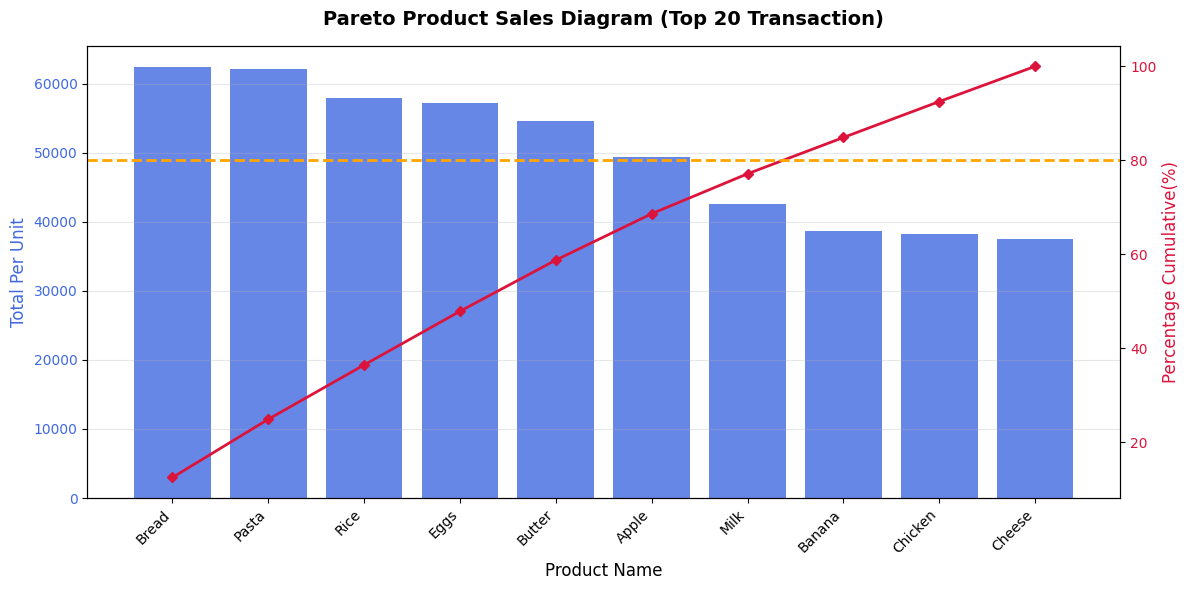

In [17]:
fig, ax1 = plt.subplots(figsize=(12,6))

df_top = df_order.head(20)

ax1.bar(df_top['product_name'], df_top['total_per_unit'], color='royalblue', alpha=0.8)
ax1.set_xlabel('Product Name', fontsize=12)
ax1.set_ylabel('Total Per Unit', fontsize=12, color='royalblue')
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.set_xticklabels(df_top['product_name'], rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(df_top['product_name'], df_top['cum_precentage'],
         color='crimson', marker='D', ms=5, linewidth=2)
ax2.set_ylabel('Percentage Cumulative(%)', color='crimson', fontsize=12)
ax2.tick_params(axis='y', labelcolor='crimson')
ax2.axhline(80, color='orange', linestyle='--', linewidth=2, label='pareto 80%')

plt.title('Pareto Product Sales Diagram (Top 20 Transaction)',
          fontsize=14, fontweight='bold', pad=15)
ax1.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

we can see the diagram, there are 7 products that are included in the vital few, namely bread, pasta, rice, eggs, butter, apple, and ,milk.
its identify by red line (percentage cumulative) intersect with orange line (cumulative limit 80%).
This means that by relying on these 7 products alone you can generate 80% profit

# Question 2: How demografi effect customer and where is the most active?

In [29]:
df_tp['date_of_birth'].info

<bound method Series.info of 0        1994-06-14 21:40:27
1        1994-06-14 21:40:27
2        1994-06-14 21:40:27
3        1994-06-14 21:40:27
4        1994-06-14 21:40:27
                ...         
10303    1967-02-18 03:49:13
10304    1967-02-18 03:49:13
10305    1967-02-18 03:49:13
10306    1989-09-03 01:58:10
10307    1989-09-03 01:58:10
Name: date_of_birth, Length: 10308, dtype: str>

In [22]:
import datetime as dt
snapshot_date = dt.datetime(2026, 6, 30)
# type casting purchase date to datetime
df_tp['purchase_date'] = pd.to_datetime(df_tp['purchase_date'])

In [32]:
# feature engineering 
df_tp['date_of_birth'] = pd.to_datetime(df_tp['date_of_birth'])
current_year = pd.Timestamp.today().year
df_tp['age'] = current_year - df_tp['date_of_birth'].dt.year

# aggregation data per customer
rfm = df_tp.groupby('customer_id').agg({
    'purchase_date': lambda x: (snapshot_date - x.max()).days,
    'purchase_id': 'count',
    'total_per_unit': 'sum',
    'age': 'first',
    'address': 'first'   
}).rename(columns={
    'purchase_date': 'recency',
    'purchase_id': 'frequency',
    'total_per_unit': 'monetary'
})

rfm.head()

,recency,frequency,monetary,age,address
customer_id,,,,,
1,1012,7,522.02,32,8465 Main St
2,969,12,423.26,37,305 Main St
3,1267,14,421.91,42,5725 Oak St
4,1004,18,749.04,40,8468 Oak St
5,1188,5,272.60,30,2820 Maple St


# Question 3: Who is new customer and how they characteristics? 